In [36]:
import pandas as pd
import numpy as np


In [37]:
df =pd.read_csv('data/Telco_cleaned.csv')

# Descriptive Statistics

### Overview of Dataset

In [38]:
print("=== 1. DATASET SHAPE ===")
print(f"Total Rows (Customers): {df.shape[0]}")
print(f"Total Columns (Features): {df.shape[1]}\n")

=== 1. DATASET SHAPE ===
Total Rows (Customers): 7032
Total Columns (Features): 20



In [39]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  Monthl

The dataset contains 20 columns covering demographic data, subscribed services, account details, and charges.

Demographics: gender, SeniorCitizen, Partner, Dependents

Services: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

Account Info: tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges

Target Variable: Churn (Yes/No)


### Analysing the Target Variable (Churn)

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

=== TARGET VARIABLE ANALYSIS ===
Raw Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64




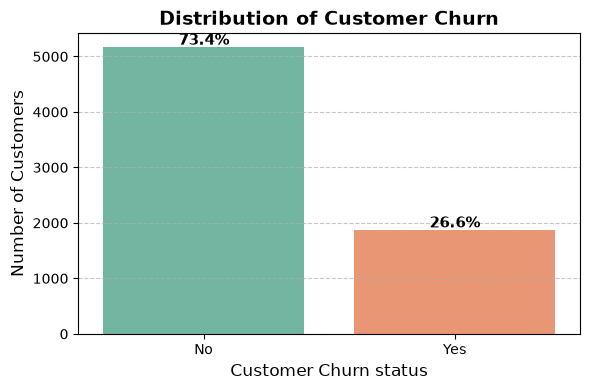

In [42]:
print("=== TARGET VARIABLE ANALYSIS ===")

# -------------------------------------------------------------
# 1. Calculate Exact Counts and Percentages
# -------------------------------------------------------------
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Raw Counts:")
print(churn_counts)
print("\nPercentages:")
print(churn_percentages.round(2))
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------
# 2. Visualize the Distribution (Count Plot)
# -------------------------------------------------------------
plt.figure(figsize=(6, 4))
# Creating a clean bar chart of Churn vs No Churn
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)

# Styling the plot
plt.title('Distribution of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the percentage labels on top of the bars
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 50
    plt.gca().annotate(percentage, (x, y), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Our data shows us that approximately 73% of the customers stay and 27% churn.

Here is Modeling Note: > Because our data is imbalanced (~73% No / ~27% Yes), Accuracy will be a trap metric. > If a  model guesses "No" for every single customer, it would instantly be 73.5% accurate, but it would catch zero of the customers who are actually leaving—making it totally useless to the business.

Therefore, during modeling, we must focus on:

Recall: To ensure we catch as many of the actual churners as possible (minimizing False Negatives).

F1-Score: To find a healthy balance between Precision and Recall.

Resampling: We might need to look into techniques like SMOTE (oversampling the minority class) or adjusting class weights when training the model.

### Numerical Features Analysis

We have three main continuous numerical variables: tenure, MonthlyCharges, and TotalCharges.


The goal in this section is to understand the shapes and distributions of our continuous variables and see exactly how they relate to whether a customer churns or stays.

To do this cleanly, I will use histograms with a kernel density estimate (KDE) overlay split by the target variable (Churn).

===NUMERIC FEATURES ANALYSIS ===


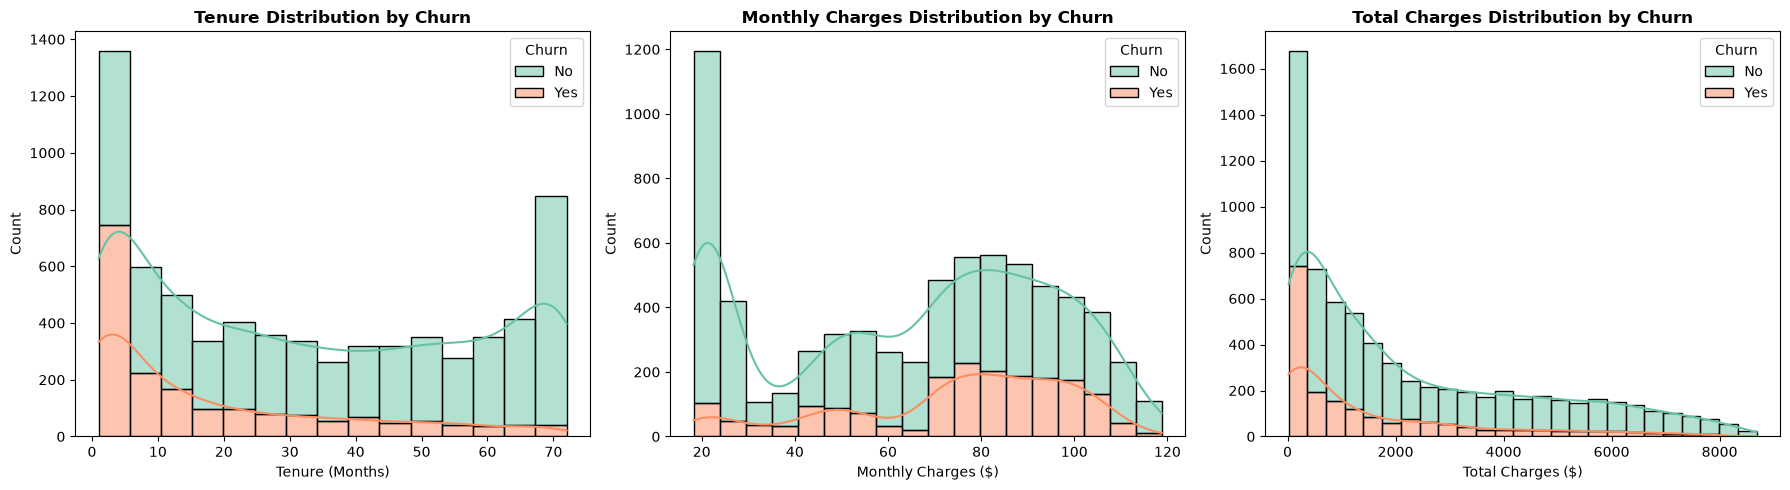

=== CORRELATION MATRIX ===


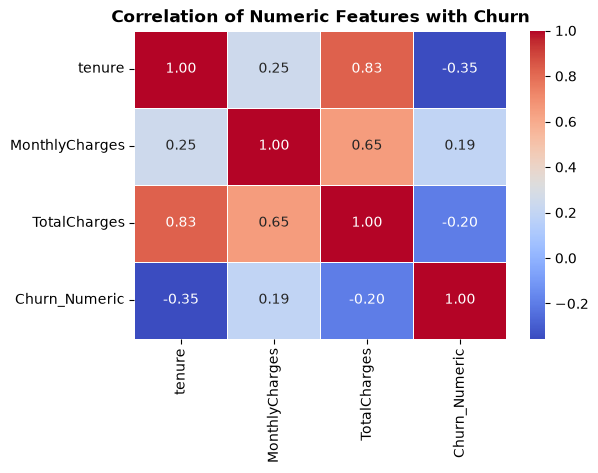

In [43]:
print("===NUMERIC FEATURES ANALYSIS ===")

# Set up a grid of 3 plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tenure Distribution
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')

# 2. Monthly Charges Distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')

# 3. Total Charges Distribution
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, multiple='stack', palette='Set2', ax=axes[2])
axes[2].set_title('Total Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Correlation Matrix (To see how numbers relate to each other)
# -------------------------------------------------------------
print("=== CORRELATION MATRIX ===")
# Convert Churn to 1/0 just for the correlation check
df_numeric_check = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_numeric_check['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(6, 4))
sns.heatmap(df_numeric_check.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation of Numeric Features with Churn', fontsize=12, fontweight='bold')
plt.show()

Tenure:

X-Axis (Horizontal): Represents Tenure, which is the continuous time variable measured in months (ranging from 1 to 72 months). It displays how long the customer has been with the company. 

Y-Axis (Vertical): Represents the Count (frequency) of customers. 

We see a huge spike in the number of customers churning at 0-3 months. Thereafter, there is a sharp decline in the graph until 20 months, but the graph continues to decrease, but at a steadier rate. 

At around 70+ months, we see the graph had dropped signigicantly indicating the highly loyal, long-tern customers.

Churn Relationship: As tenure increases, the probability of churn drops significantly.

Monthly Charges:

This distribution shows a  spike around $20, the cheap end. There is a huge spike of users there with fewer churning. This represents low-risk users (likely basic phone-only plans).

 The rate of churning increases significantly from $70 to $100 range with around 200 customers leaving the services. High prices clearly frustrate users or drive them to seek competitor deals.

Churn Relationship: Higher monthly charges generally correlate with a higher likelihood of churn.

TotalCharges:

The graph is heavily skewed to the left because most customers have lower total payments, while a few long-term customers accumulate high totals.

### Categorical Features Analysis

I have categorical data (text labels) and with target outcome (Churn: Yes/No). I need a statistical graphic that helps me to see which categories have the highest volume of customers, and within those categories, what proportion are leaving?

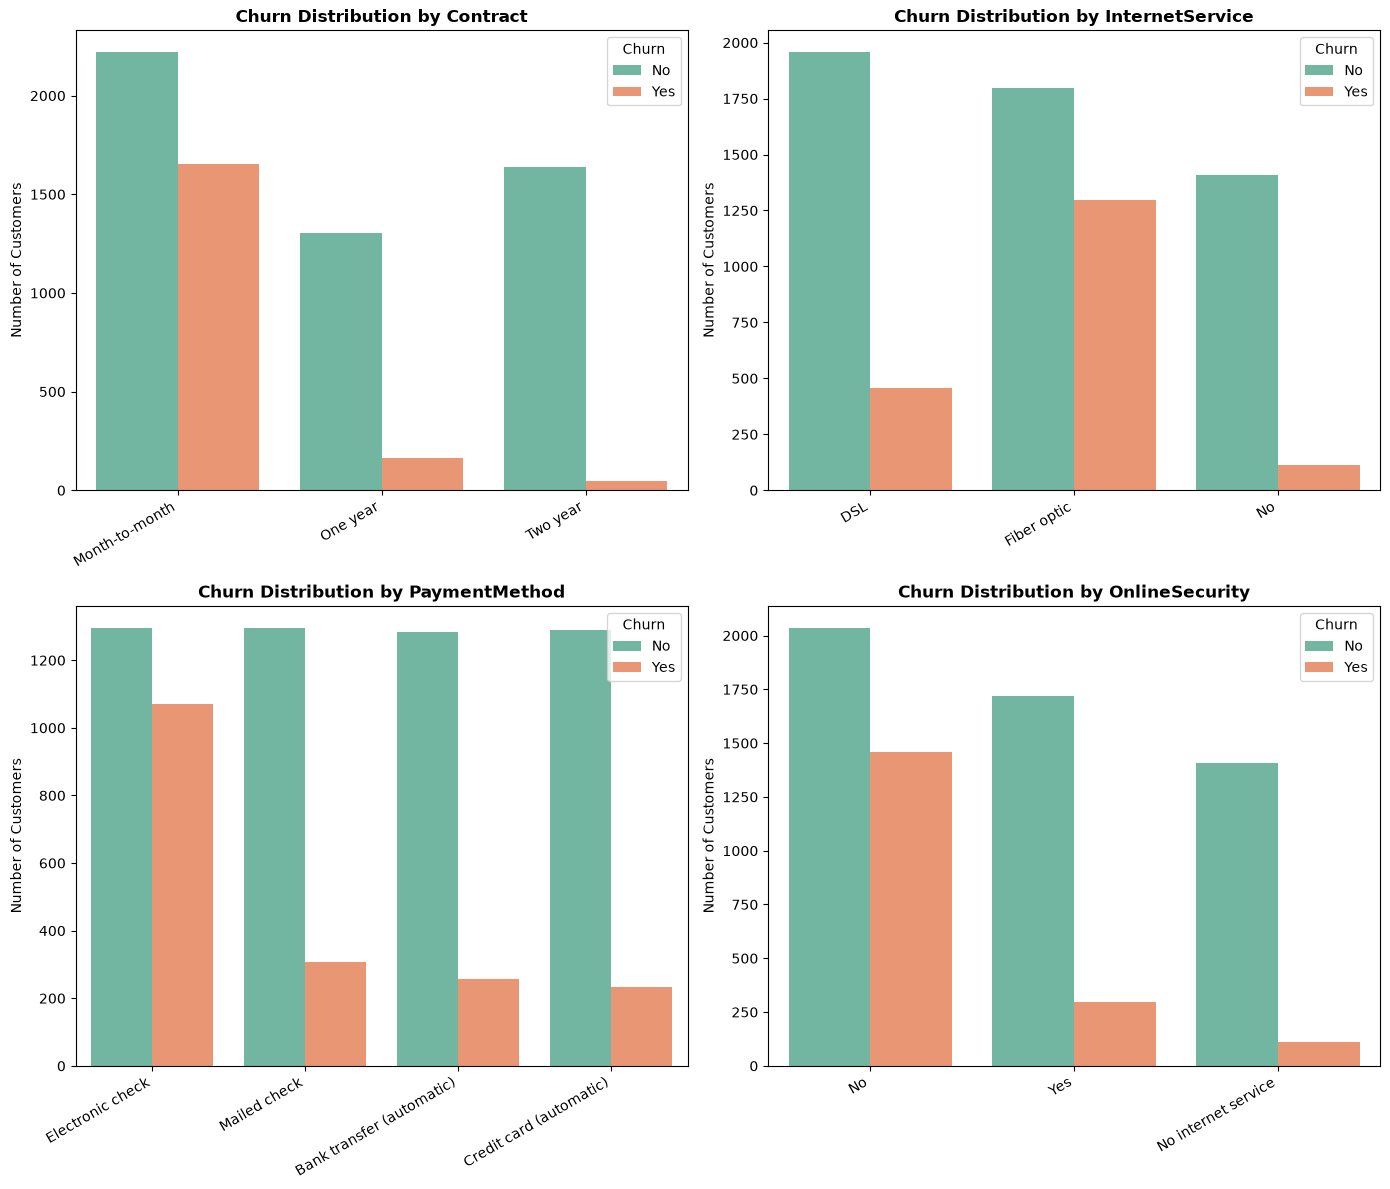

In [46]:


# Here are the categorical features I want to analyse
features_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

# Setting up the grid dimensions dynamically
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Looping through features and build the plots
for i, col in enumerate(features_to_plot):
    # Create the countplot with Churn as the color breakdown
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    
    #Clean up aesthetics
    axes[i].set_title(f'Churn Distribution by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Remove redundant x-axis label
    axes[i].set_ylabel('Number of Customers')
    
    # Rotate long text labels so they don't overlap
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

# Adjustment of layout and display
plt.tight_layout()
plt.show()